In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import trange

from obstacles import create_obstacle_data
from utils.config import Config
from utils.tools import calc_sig_strength_gpu

In [2]:
data_path = './result'
height_files = sorted([os.path.join(str(data_path), df) for df in os.listdir(data_path) if "mode_height" in df], key=str.lower)
num_gu_files = sorted([os.path.join(str(data_path), df) for df in os.listdir(data_path) if "mode_num_gu" in df], key=str.lower)
num_gu_files, height_files

(['./result/eval_mode_num_gu_U2_H70.csv',
  './result/eval_mode_num_gu_U3_H70.csv',
  './result/eval_mode_num_gu_U4_H70.csv',
  './result/eval_mode_num_gu_U5_H70.csv',
  './result/eval_mode_num_gu_U6_H70.csv'],
 ['./result/eval_mode_height_U4_H50.csv',
  './result/eval_mode_height_U4_H60.csv',
  './result/eval_mode_height_U4_H70.csv',
  './result/eval_mode_height_U4_H80.csv',
  './result/eval_mode_height_U4_H90.csv'])

In [3]:
gus_ls = [pd.read_csv(pth) for pth in num_gu_files ]
height_ls = [pd.read_csv(pth) for pth in height_files]

In [4]:
gus_ls[0]

,gnd1_x,gnd1_y,gnd1_z,gnd2_x,gnd2_y,gnd2_z,bf_x,bf_y,bf_z,cent_x,cent_y,cent_z,prob_x,prob_y,prob_z,ours_x,ours_y,ours_z
0,-26.767437,6.268194,0.0,88.384040,-87.657820,0.0,-54.4,-81.4,70.0,30.808302,-40.694813,70.0,-3.799995,-12.500000,70.0,-53.775700,-86.274090,70.0
1,55.767940,-35.689270,0.0,59.672470,-78.144710,0.0,60.6,-57.0,70.0,57.720207,-56.916990,70.0,57.699997,-56.899998,70.0,60.257980,-78.093290,70.0
2,98.382770,37.109630,0.0,-87.915470,-87.780594,0.0,98.4,-83.0,70.0,5.233650,-25.335482,70.0,91.600006,32.600006,70.0,-89.528440,-99.994804,70.0
3,-45.098457,-69.351880,0.0,31.152685,-42.510350,0.0,-35.6,-60.7,70.0,-6.972886,-55.931114,70.0,-7.000000,-55.899998,70.0,-36.766000,-48.557410,70.0
4,-25.741870,-45.459830,0.0,76.901040,1.328164,0.0,75.3,-49.5,70.0,25.579584,-22.065834,70.0,25.500000,-22.099998,70.0,47.908157,-50.241962,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,63.434612,27.262152,0.0,89.514490,14.461929,0.0,75.8,19.3,70.0,76.474550,20.862041,70.0,76.500000,20.900002,70.0,66.034454,18.130447,70.0
9996,-8.438369,92.321400,0.0,59.545433,41.172830,0.0,59.4,81.4,70.0,25.553532,66.747116,70.0,25.500000,66.800000,70.0,59.085648,100.000000,70.0
9997,1.079207,11.488510,0.0,-73.777670,99.915920,0.0,-12.9,44.9,70.0,-36.349230,55.702213,70.0,-36.399998,55.699997,70.0,-99.853800,51.591812,70.0
9998,-27.469890,18.564686,0.0,17.119576,-6.612558,0.0,13.9,22.9,70.0,-5.175158,5.976064,70.0,-5.199997,6.000000,70.0,6.066444,29.004822,70.0


In [5]:
cfg = Config.performance_eval()
gus_x = []
gus_bf, gus_ours, gus_prob, gus_cent = [], [], [], []
dist_ours, dist_prob, dist_cent = [], [], []
obstacle_ls, obst_tensor = create_obstacle_data(cfg=cfg, return_type='both')

for df in gus_ls:
    gus = torch.tensor(df.iloc[:,:-12].values, dtype=torch.float32, device=cfg.device)
    bf = torch.tensor(df.iloc[:,-12:-9].values, dtype=torch.float32, device=cfg.device)
    cent = torch.tensor(df.iloc[:,-9:-6].values, dtype=torch.float32, device=cfg.device)
    prob = torch.tensor(df.iloc[:,-6:-3].values, dtype=torch.float32, device=cfg.device)
    ours = torch.tensor(df.iloc[:,-3:].values, dtype=torch.float32, device=cfg.device)

    gus_x.append(int(gus.shape[1]/3))

    bf_result = 0
    centroid_result = 0
    prob_result = 0
    ours_result = 0
    gus = gus.reshape(-1, gus_x[-1], 3)

    for i in trange(len(gus), desc=f"Calc Result U{gus_x[-1]}"):
        bf_result += calc_sig_strength_gpu(bf[i].unsqueeze(0), gus[i], obst_tensor, cfg)
        centroid_result += calc_sig_strength_gpu(cent[i].unsqueeze(0), gus[i], obst_tensor, cfg)
        prob_result += calc_sig_strength_gpu(prob[i].unsqueeze(0), gus[i], obst_tensor, cfg)
        ours_result += calc_sig_strength_gpu(ours[i].unsqueeze(0), gus[i], obst_tensor, cfg)

    bf_result /= len(gus)
    centroid_result /= len(gus)
    prob_result /= len(gus)
    ours_result /= len(gus)
    gus_bf.append(float(bf_result))
    gus_cent.append(float(centroid_result))
    gus_prob.append(float(prob_result))
    gus_ours.append(float(ours_result))


Calc Result U6: 100%|██████████| 10000/10000 [00:27<00:00, 368.64it/s]


In [6]:
height_x = []
height_bf, height_ours, height_prob, height_cent = [], [], [], []

for df in height_ls:
    gus = torch.tensor(df.iloc[:,:-12].values, dtype=torch.float32, device=cfg.device)
    bf = torch.tensor(df.iloc[:,-12:-9].values, dtype=torch.float32, device=cfg.device)
    cent = torch.tensor(df.iloc[:,-9:-6].values, dtype=torch.float32, device=cfg.device)
    prob = torch.tensor(df.iloc[:,-6:-3].values, dtype=torch.float32, device=cfg.device)
    ours = torch.tensor(df.iloc[:,-3:].values, dtype=torch.float32, device=cfg.device)

    height_x.append(int(bf[0,-1].item()))

    bf_result = 0
    centroid_result = 0
    prob_result = 0
    ours_result = 0
    gus = gus.reshape(-1, int(gus.shape[1]/3), 3)

    for i in trange(len(gus), desc=f"Calc Result H{height_x[-1]}"):
        bf_result += calc_sig_strength_gpu(bf[i].unsqueeze(0), gus[i], obst_tensor, cfg)
        centroid_result += calc_sig_strength_gpu(cent[i].unsqueeze(0), gus[i], obst_tensor, cfg)
        prob_result += calc_sig_strength_gpu(prob[i].unsqueeze(0), gus[i], obst_tensor, cfg)
        ours_result += calc_sig_strength_gpu(ours[i].unsqueeze(0), gus[i], obst_tensor, cfg)

    bf_result /= len(gus)
    centroid_result /= len(gus)
    prob_result /= len(gus)
    ours_result /= len(gus)
    height_bf.append(float(bf_result))
    height_cent.append(float(centroid_result))
    height_prob.append(float(prob_result))
    height_ours.append(float(ours_result))


Calc Result H90: 100%|██████████| 10000/10000 [00:26<00:00, 378.02it/s]


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


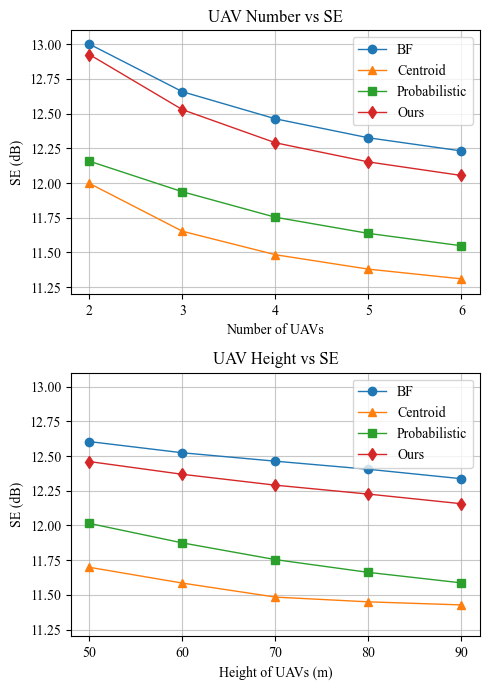

In [38]:
plt.figure(figsize=(5, 7))
plt.rcParams['font.family'] = 'Times New Roman'
plt.subplot(2, 1, 1)
plt.plot(gus_x, gus_bf, label='BF', marker='o', linewidth=1)
plt.plot(gus_x, gus_cent, label='Centroid', marker='^', linewidth=1)
plt.plot(gus_x, gus_prob, label='Probabilistic', marker='s', linewidth=1)
plt.plot(gus_x, gus_ours, label='Ours', marker='d', linewidth=1)
plt.title("UAV Number vs SE")
plt.xlabel("Number of UAVs")
plt.ylabel("SE (dB)")
plt.xticks(gus_x)
plt.ylim(11.2, 13.1)
plt.legend()
plt.grid(True)
plt.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.7)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

plt.subplot(2, 1, 2)
plt.plot(height_x, height_bf, label='BF', marker='o', linewidth=1)
plt.plot(height_x, height_cent, label='Centroid', marker='^', linewidth=1)
plt.plot(height_x, height_prob, label='Probabilistic', marker='s', linewidth=1)
plt.plot(height_x, height_ours, label='Ours', marker='d', linewidth=1)
plt.title("UAV Height vs SE")
plt.xlabel("Height of UAVs (m)")
plt.ylabel("SE (dB)")
plt.xticks(height_x)
plt.ylim(11.2, 13.1)
plt.legend()
plt.grid(True)
plt.grid(which='major', linestyle='-', linewidth=0.8, alpha=0.7)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join('result', 'performance_eval_1.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join('result', 'performance_eval_1.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join('result', 'performance_eval_1.eps'), dpi=300, bbox_inches='tight')
plt.show()
